<div style="font-family: 'Times New Roman'; font-size: 12pt; line-height: 1.6; position: relative;">

<!-- Top Right Image -->
<div style="position: absolute; top: 0; right: 0;">
    <img src="WhatsApp Image 2026-02-25 at 12.03.28 PM.jpeg" width="250">
</div>

<h1 style="font-size:16pt; font-weight:bold;">
CIA 3 : Final Model and Report Submission
</h1>

<h2 style="font-size:14pt; font-weight:bold;">
Advanced Linear Regression: Spotify Tracks Data Analysis
</h2>

<h3 style="font-size:14pt; font-weight:bold;">
Authors:
</h3>

<ul>
<li><strong>Kushal Surana</strong> — 2333326</li>
<li><strong>Aditi Chauhan</strong> — 2333405</li>
<li><strong>Ankita Bajoria</strong> — 2333412</li>
<li><strong>Khush Sawansukha</strong> — 2333429</li>
</ul>

<br><br><br>

<!-- Bottom Images -->
<div style="text-align: center;">
    <img src="Spotify1.png" width="350" style="margin-right:20px;">
    <img src="Spotify2.png" width="350">
</div>

</div>

<div style="font-family: 'Times New Roman'; font-size: 12pt; line-height: 1.6;">

<h2 style="font-size:14pt; font-weight:bold;">Abstract</h2>

This project analyzes Spotify data to understand how different song features such as danceability, energy, tempo, and loudness influence a song’s popularity. First, the dataset was loaded, cleaned, and explored using basic statistical methods and visualizations. An <strong>Ordinary Least Squares (OLS)</strong> linear regression model was then developed to predict popularity based on these features. The model’s performance was evaluated using error measures and residual plots. The results indicate that certain audio features have a significant impact on popularity; however, the model does not capture all influencing factors. Overall, the study shows that Spotify song features can partially predict popularity, while other external factors also play an important role.

</div>

<div style="font-family: 'Times New Roman'; font-size: 12pt; line-height: 1.6;">

<h2 style="font-size:14pt; font-weight:bold;">Introduction</h2>

The rapid growth of digital music streaming has transformed the way audiences consume music. Platforms like Spotify generate massive amounts of structured data describing each track’s audio characteristics. This dataset contains quantitative musical attributes such as <strong>danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo</strong>, and a popularity score assigned by the platform. Each row represents a single song, and each column captures a measurable musical property derived from signal processing algorithms.

The <strong>popularity</strong> variable serves as the dependent (target) variable in this study. It reflects how well a track performs relative to others on the platform, based on listening frequency and user engagement patterns. Unlike subjective measures such as ratings, popularity is a numerical score, making it suitable for statistical modeling.

The independent variables in the dataset are objective audio features:

• <strong>Danceability</strong> measures how suitable a track is for dancing based on tempo, rhythm stability, and beat strength.  
• <strong>Energy</strong> reflects intensity and activity level.  
• <strong>Loudness</strong> represents overall amplitude of the track in decibels.  
• <strong>Speechiness</strong> indicates the presence of spoken words.  
• <strong>Acousticness</strong> estimates whether a track is acoustic.  
• <strong>Instrumentalness</strong> predicts whether a track contains vocals.  
• <strong>Liveness</strong> detects the presence of a live audience.  
• <strong>Valence</strong> measures musical positivity (happy vs. sad tone).  
• <strong>Tempo</strong> captures beats per minute (BPM).

These features are continuous numerical variables, which makes them appropriate inputs for regression analysis.

</div>

<div style="font-family: 'Times New Roman'; font-size: 12pt; line-height: 1.6;">

<h2 style="font-size:14pt; font-weight:bold;">Objectives of the Study</h2>

1. To analyze the Spotify track dataset and understand the structure of its numerical audio features.

2. To examine the relationship between audio characteristics (<strong>danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, and tempo</strong>) and track popularity.

3. To apply <strong>Ordinary Least Squares (OLS) regression</strong> to model popularity as a function of audio features.

4. To determine which audio features have a statistically significant impact on popularity using coefficient estimates and p-values.

5. To evaluate the explanatory power of the regression model using <strong>R²</strong> and error metrics.

6. To assess whether the assumptions of linear regression (<strong>linearity, normality of residuals, and homoscedasticity</strong>) are reasonably satisfied.

7. To interpret the results and determine the extent to which measurable musical attributes explain variations in Spotify track popularity.

</div>

<div style="font-family: 'Times New Roman'; font-size: 12pt; line-height: 1.6;">

<h2 style="font-size:14pt; font-weight:bold;">Research Question</h2>

Can a linear regression model accurately predict song popularity using Spotify audio data?

</div>

<div style="font-family: 'Times New Roman'; font-size: 12pt; line-height: 1.6;">

<h2 style="font-size:14pt; font-weight:bold;">Problem Statement</h2>

With the rapid growth of music streaming platforms such as Spotify, a large volume of data is generated on songs and their audio characteristics. However, the relationship between these audio features and a song’s popularity is not yet clearly understood. This lack of clarity makes it difficult for artists and music producers to predict which songs are likely to perform well.

Therefore, this study aims to examine the relationship between Spotify’s audio features and song popularity using <strong>Ordinary Least Squares (OLS) regression</strong>, in order to identify how different features influence popularity and contribute to a song’s success.

</div>


<h1 style='color: black; font-family:Times New Roman; font-weight:bold; font-style:italics; text-align:center; font-size:35px;'> Analysis</h1>


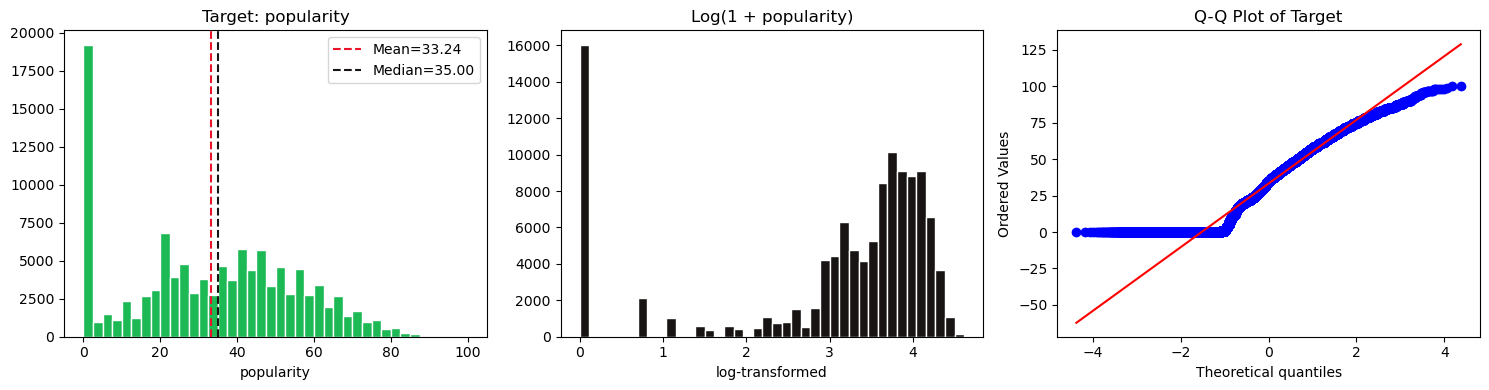

Skewness (raw)   : 0.046
Skewness (log+1) : -1.348
Kurtosis (raw)   : -0.928


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Load dataset
df = pd.read_csv("spotify-tracks-dataset (1).csv")

# Define colors (since you used BLUE, RED, GREEN before)
BLUE = "#1DB954"   # Spotify green vibe
RED = "#E91429"
GREEN = "#191414"

# Target variable (change this if your target is different)
target = "popularity"

# Create plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1️⃣ Histogram (Raw)
axes[0].hist(df[target], bins=40, color=BLUE, edgecolor='white')
axes[0].axvline(df[target].mean(), 
                color=RED, linestyle='--',
                label=f'Mean={df[target].mean():.2f}')
axes[0].axvline(df[target].median(), 
                color=GREEN, linestyle='--',
                label=f'Median={df[target].median():.2f}')
axes[0].set_title(f'Target: {target}')
axes[0].set_xlabel(target)
axes[0].legend()

# 2️⃣ Log Transformation
axes[1].hist(np.log1p(df[target]), bins=40, 
             color=GREEN, edgecolor='white')
axes[1].set_title(f'Log(1 + {target})')
axes[1].set_xlabel('log-transformed')

# 3️⃣ Q-Q Plot
stats.probplot(df[target], dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot of Target')

plt.tight_layout()
plt.show()

# 📊 Distribution stats
print(f'Skewness (raw)   : {df[target].skew():.3f}')
print(f'Skewness (log+1) : {np.log1p(df[target]).skew():.3f}')
print(f'Kurtosis (raw)   : {df[target].kurt():.3f}')

<div style="font-family: 'Times New Roman'; font-size: 12pt; line-height: 1.6;">

<h2 style="font-size:14pt;">Distribution and Normality Assessment of Popularity</h2>

The three graphs are examining the **distribution of the target variable (popularity)** and whether it satisfies the **normality assumption required for OLS regression**.

---

<h3 style="font-size:14pt;">1. Raw Popularity Distribution</h3>

The first histogram shows the raw popularity distribution. 

The mean is approximately <strong>33.24</strong> and the median is <strong>35.00</strong>, which are very close. This indicates the distribution is fairly symmetric around the center. The reported skewness of <strong>0.046</strong> confirms this — the distribution is almost perfectly symmetric. 

The kurtosis value of <strong>-0.928</strong> suggests a flatter-than-normal distribution (<strong>platykurtic</strong>), meaning the data has lighter tails and fewer extreme outliers compared to a normal distribution.

However, visually, there is a noticeable spike near zero popularity. That spike indicates many tracks have very low popularity, creating a heavy concentration at the lower bound. This boundary effect exists because popularity is restricted between <strong>0 and 100</strong>. 

Even though overall skewness is near zero, the lower-bound clustering creates a non-smooth shape that is not perfectly normal.

---

<h3 style="font-size:14pt;">2. Log Transformation of Popularity</h3>

The second histogram shows the <strong>log(1 + popularity)</strong> transformation. 

Instead of improving normality, the transformation introduces strong negative skewness (<strong>-1.348</strong>). This happens because the original data was already fairly symmetric. Applying a log transformation to a symmetric bounded variable compresses higher values and stretches lower values, distorting the distribution.

In short, the log transformation was unnecessary and made the distribution worse. The left tail becomes more elongated, and the overall shape moves away from normality.

---

<h3 style="font-size:14pt;">3. Q-Q Plot Analysis</h3>

The Q-Q plot confirms the non-normal nature of the target variable.

If the data were normally distributed, the blue points would follow the red straight line closely. Instead, the points deviate significantly, especially in the lower and upper tails.

There is a clear flattening at the lower end (many values near zero), which reflects the bounded nature of popularity scores. The upper tail also bends away from the line, indicating departures from normality at higher popularity values.

---

<h3 style="font-size:14pt;">Overall Interpretation</h3>

The raw popularity variable is roughly symmetric but not normally distributed due to boundary constraints and clustering at low values.

The log transformation worsens the distribution rather than improving it.

Since OLS assumes normality of <strong>residuals</strong> (not the target variable itself), this does not automatically invalidate the model. However, these plots indicate that popularity is not truly continuous and normally distributed, which partially explains why the regression model has very low explanatory power.

</div>

<h1 style='color: black; font-family:Times New Roman; font-weight:bold; font-style:italics; text-align:center; font-size:35px;'> Correlation Matrix </h1>


C:\Users\aditi chauhan\Documents\annaconda\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


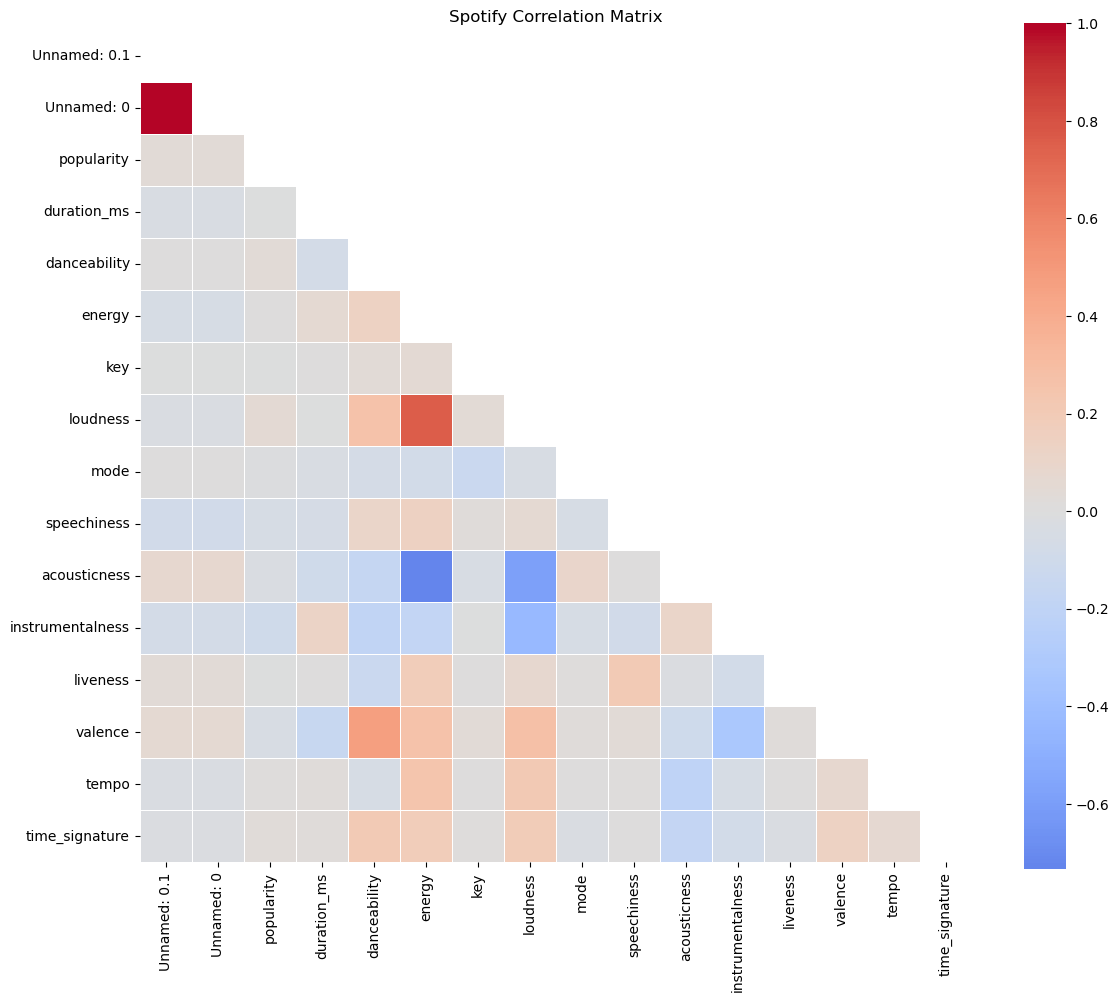

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns
spotify_numeric = df.select_dtypes(include=['number'])

# Correlation matrix
corr = spotify_numeric.corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Spotify Correlation Matrix")
plt.tight_layout()
plt.show()

<div style="font-family: 'Times New Roman'; font-size: 12pt; line-height: 1.6;">

<h2 style="font-size:14pt; font-weight:bold;">Correlation Matrix Analysis</h2>

The correlation matrix shows the pairwise linear relationships between all numerical variables in the Spotify dataset. The color scale ranges from negative correlation (blue) to positive correlation (red), with values close to zero appearing neutral. The diagonal elements are all <strong>1.0</strong> because each variable is perfectly correlated with itself.

The most striking relationship in the matrix is the strong positive correlation between <strong>energy and loudness</strong>. This is expected, since louder songs tend to feel more energetic. This high correlation suggests potential <strong>multicollinearity</strong>, meaning these two variables carry overlapping information in the regression model. While it may not completely distort the model, it weakens the independent interpretability of their coefficients.

There is also a strong negative correlation between <strong>energy and acousticness</strong>. This makes intuitive sense: highly acoustic tracks are usually less intense and therefore less energetic. Similarly, acousticness appears negatively correlated with loudness. These relationships reflect logical musical patterns rather than statistical anomalies.

<strong>Valence</strong> shows a moderate positive relationship with energy and loudness, indicating that more energetic and louder tracks tend to sound more positive or happy. However, valence does not show a strong direct correlation with popularity, which aligns with the earlier regression results showing that popularity is not strongly explained by any single feature.

<strong>Instrumentalness</strong> shows a negative relationship with loudness and energy, and weak correlation with popularity. This supports the regression finding that instrumental tracks tend to be less popular, but the correlation magnitude is not large.

<strong>Popularity</strong> itself does not display strong correlations with any individual audio feature. Most correlations between popularity and other variables appear weak and close to zero. This visually confirms what the regression results already showed: audio features have limited linear relationship with popularity.

Other features such as <strong>key</strong>, <strong>mode</strong>, and <strong>time_signature</strong> exhibit near-zero correlations with most variables, indicating they likely contribute very little explanatory power in a linear model.

<h3 style="font-size:14pt; font-weight:bold;">Overall Interpretation</h3>

Overall, the matrix reveals that while some audio features are strongly related to each other (energy–loudness, energy–acousticness), their direct linear relationship with popularity is weak. This explains why the OLS model produced a very low <strong>R-squared value</strong>. The predictors contain internal relationships, but they do not strongly explain the target variable.

</div>

<h1 style='color: black; font-family:Times New Roman; font-weight:bold; font-style:italics; text-align:center; font-size:35px;'>Scatter Plot</h1>


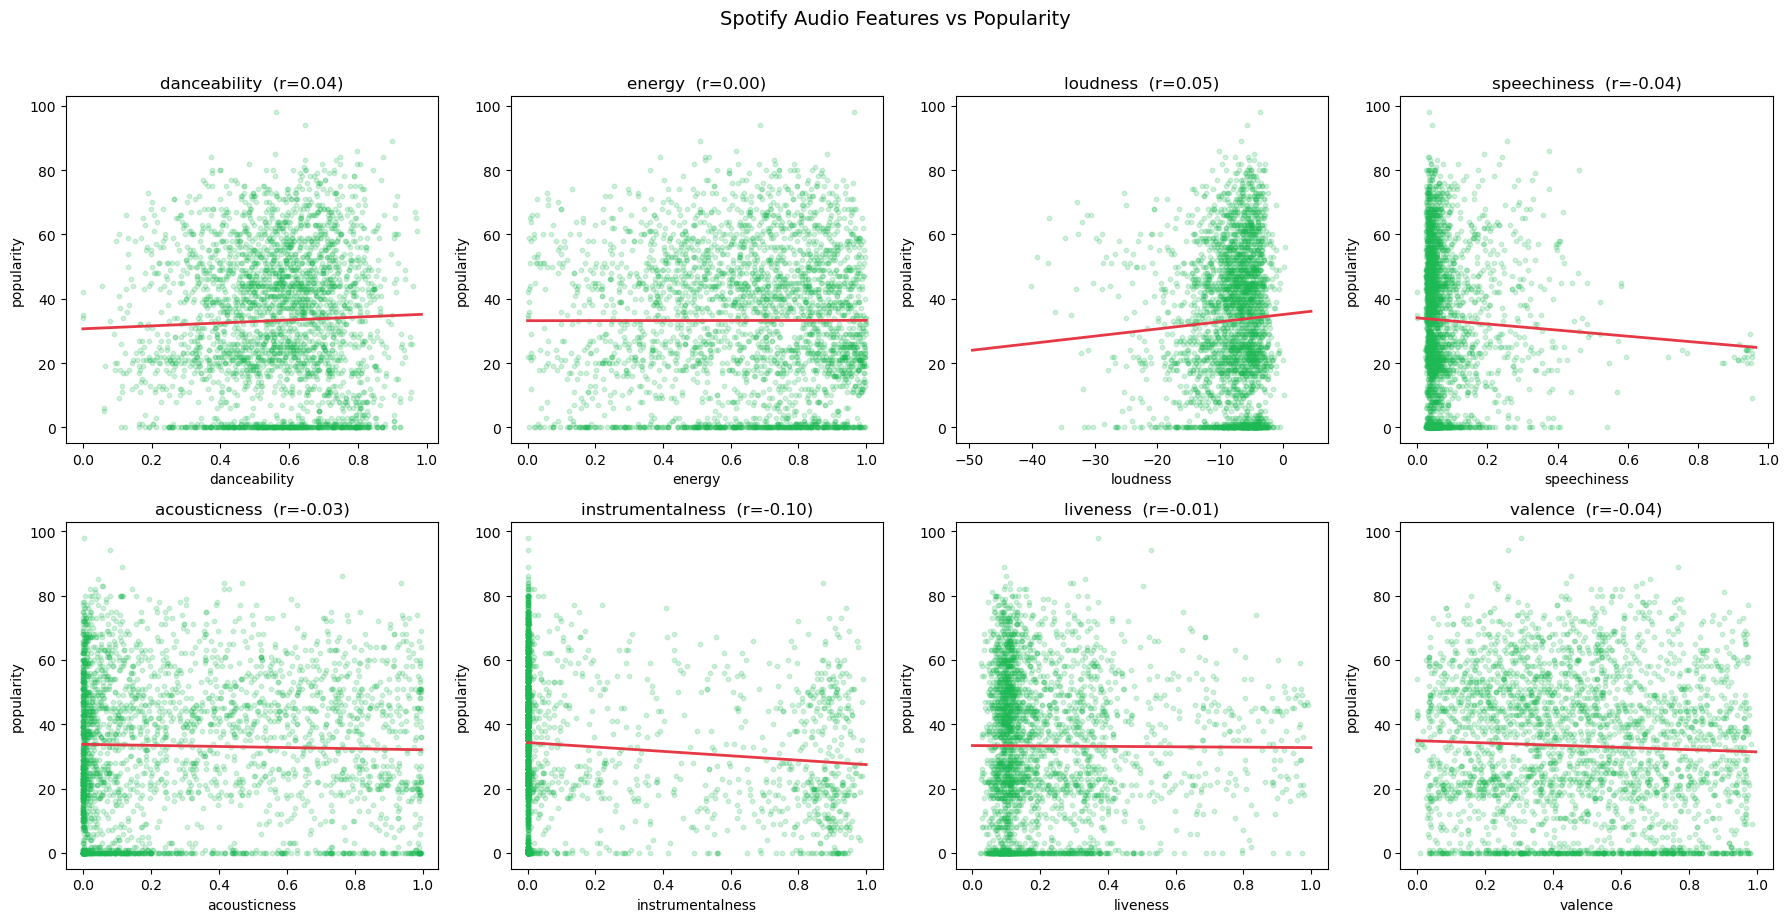

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Define target variable
TARGET = 'popularity'

# Define Spotify audio features (edit if needed)
FEATURES = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence'
]

# Colors
BLUE = "#1DB954"
RED = "#E63946"

# Remove missing values
df = df.dropna(subset=FEATURES + [TARGET])

# Subsample safely
sample_size = min(3000, len(df))
idx_samp = np.random.choice(len(df), sample_size, replace=False)

# Correlation matrix
corr = df[FEATURES + [TARGET]].corr()

# Create plots
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    
    # Scatter
    axes[i].scatter(
        df[feat].iloc[idx_samp],
        df[TARGET].iloc[idx_samp],
        alpha=0.2,
        s=10,
        color=BLUE
    )
    
    # Regression line
    m, b = np.polyfit(df[feat], df[TARGET], 1)
    xr = np.linspace(df[feat].min(), df[feat].max(), 100)
    axes[i].plot(xr, m * xr + b, color=RED, linewidth=2)
    
    # Correlation
    r = corr[feat][TARGET]
    
    axes[i].set_title(f'{feat}  (r={r:.2f})')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel(TARGET)

plt.suptitle('Spotify Audio Features vs Popularity', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

<div style="font-family: 'Times New Roman'; font-size: 12pt; line-height: 1.6;">

<h2 style="font-size:14pt; font-weight:bold;">Scatterplot Analysis of Audio Features and Popularity</h2>

These show the relationship between each Spotify audio feature and popularity, along with a fitted linear trend line and correlation coefficient (<strong>r</strong>). The key takeaway across all plots is simple: the relationships are <strong>extremely weak</strong>.

Starting with <strong>danceability (r = 0.04)</strong>, the slope is slightly positive, meaning more danceable songs tend to have marginally higher popularity. However, the correlation is near zero. The points are widely scattered with no clear upward pattern. This indicates almost no meaningful linear relationship.

<strong>Energy (r = 0.00)</strong> is effectively uncorrelated with popularity. The trend line is almost flat. This confirms that energetic songs are neither clearly more nor less popular in a linear sense.

<strong>Loudness (r = 0.05)</strong> shows a very slight positive relationship. Louder songs appear marginally more popular, but again the correlation is extremely weak. The data points are widely dispersed vertically, meaning popularity varies greatly at every loudness level.

<strong>Speechiness (r = −0.04)</strong> shows a weak negative relationship. Songs with more spoken-word characteristics tend to be slightly less popular. However, the effect is minimal and the scatter is dense at low speechiness values, indicating most tracks cluster in that region.

<strong>Acousticness (r = −0.03)</strong> also shows a weak negative relationship. More acoustic songs appear slightly less popular, but the trend is almost flat. There is no strong directional pattern.

<strong>Instrumentalness (r = −0.10)</strong> shows the strongest relationship among the plots, but even this is weak. The negative slope suggests that more instrumental tracks tend to have lower popularity. This is consistent with mainstream trends where vocal tracks dominate charts. Still, <strong>r = −0.10</strong> is considered a very weak correlation.

<strong>Liveness (r = −0.01)</strong> is essentially unrelated to popularity. The trend line is flat and points are randomly scattered.

<strong>Valence (r = −0.04)</strong> shows a very weak negative relationship, suggesting happier-sounding songs might be slightly less popular, but again the effect is trivial.

<h3 style="font-size:14pt; font-weight:bold;">Overall Interpretation</h3>

Overall interpretation: none of the audio features show a strong linear relationship with popularity. All correlation values are between <strong>−0.10 and +0.05</strong>, which are extremely small. The scatter patterns are broad and diffuse, meaning popularity varies widely regardless of feature level. These visuals strongly support the regression result where <strong>R² was only 2.25%</strong>. The data simply does not contain strong linear predictive signals between audio characteristics and popularity.

</div>

<h1 style='color: black; font-family:Times New Roman; font-weight:bold; font-style:italics; text-align:center; font-size:35px;'> Box Plot </h1>


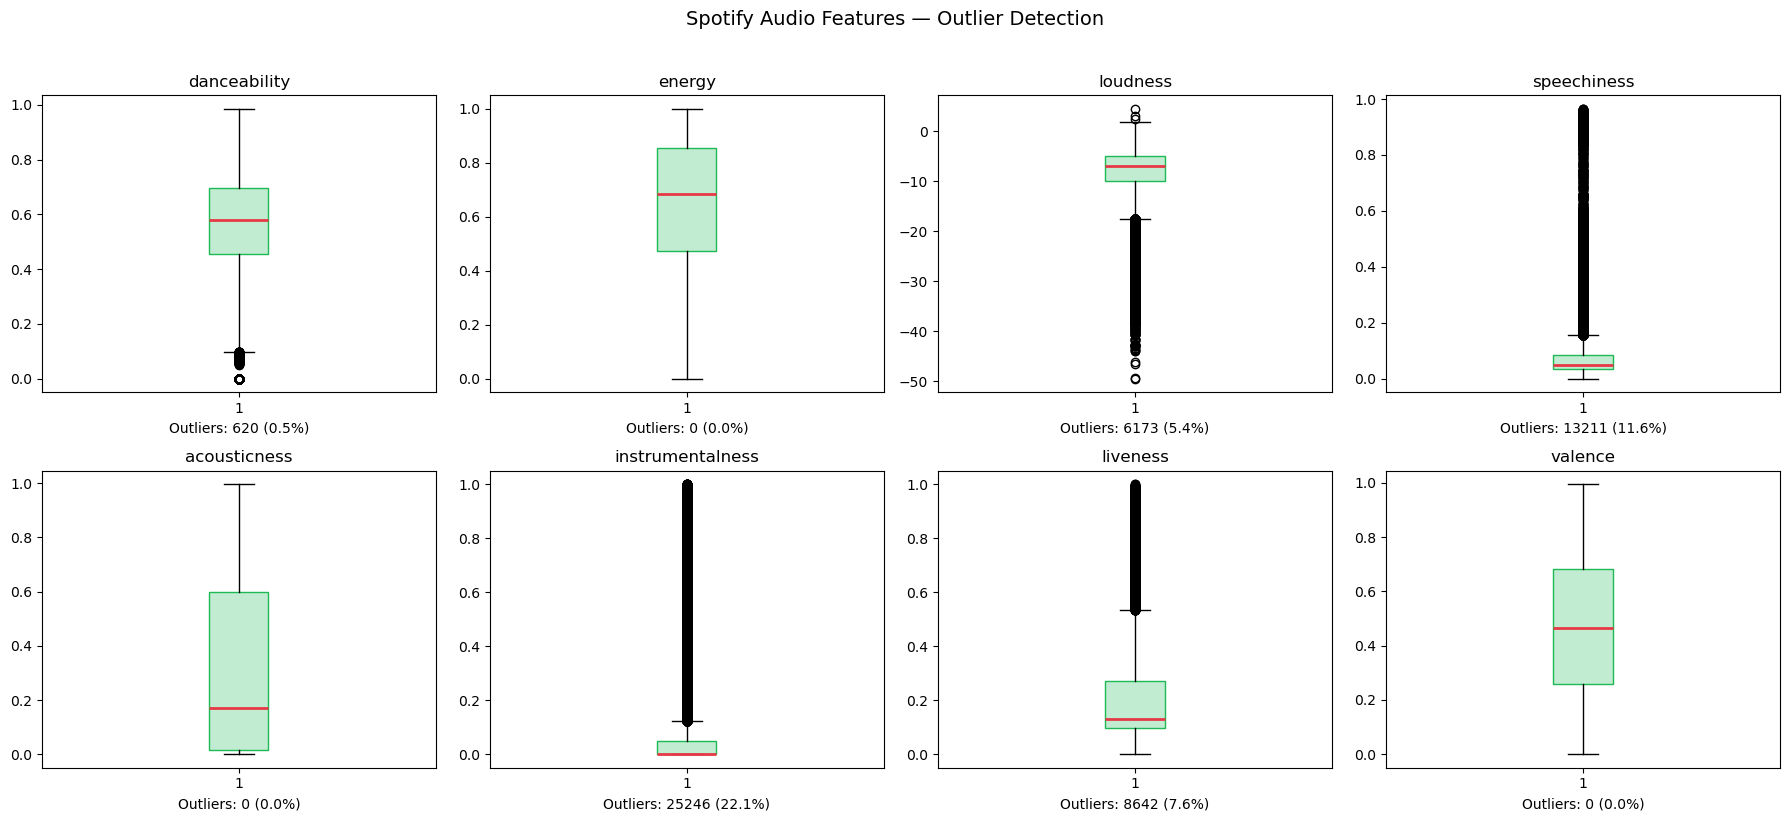

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Define Spotify audio features (edit if needed)
FEATURES = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence'
]

# Colors
BLUE = "#1DB954"
RED = "#E63946"

# Remove missing values
df = df.dropna(subset=FEATURES)

# Create subplot grid
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    
    axes[i].boxplot(
        df[feat],
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor=BLUE + '44', color=BLUE),
        medianprops=dict(color=RED, linewidth=2)
    )
    
    axes[i].set_title(feat)
    
    # IQR outlier calculation
    q1, q3 = df[feat].quantile([0.25, 0.75])
    iqr = q3 - q1
    out = ((df[feat] < q1 - 1.5 * iqr) | 
           (df[feat] > q3 + 1.5 * iqr)).sum()
    
    axes[i].set_xlabel(f'Outliers: {out} ({out/len(df)*100:.1f}%)')

plt.suptitle('Spotify Audio Features — Outlier Detection', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

<div style="font-family: 'Times New Roman'; font-size: 12pt; line-height: 1.6;">

<h2 style="font-size:14pt; font-weight:bold;">Boxplot Analysis of Spotify Audio Features</h2>

These show the distribution of each Spotify audio feature and identify potential outliers using the <strong>interquartile range (IQR) method</strong>. Each box represents the middle 50% of the data, the line inside is the median, whiskers extend to typical range limits, and points beyond them are classified as outliers.

Starting with <strong>danceability</strong>, the distribution is fairly centered around moderate values, with a median slightly above 0.5. Only 0.5% of observations are flagged as outliers, which is very low. This suggests danceability is relatively well-behaved and symmetrically distributed.

<strong>Energy</strong> shows a wider spread but no detected outliers (0.0%). The distribution covers nearly the full 0–1 range, indicating strong variability across songs but without extreme deviations outside the IQR limits.

<strong>Loudness</strong> displays noticeable lower-end outliers (5.4%). Since loudness is measured in decibels and bounded on the lower side for very quiet tracks, extreme negative values appear as outliers. This makes sense for unusually quiet or non-standard recordings.

<strong>Speechiness</strong> shows 11.0% outliers, which is substantial. Most tracks cluster near low speechiness values (typical for music rather than spoken content), but a significant number extend toward higher values. These higher speechiness tracks are likely rap, spoken word, or podcast-like content, which structurally differ from typical songs.

<strong>Acousticness</strong> shows no outliers (0.0%), even though the distribution is skewed toward lower values. The spread appears broad but not extreme relative to its IQR.

<strong>Instrumentalness</strong> stands out with 22.1% outliers, the highest among all features. This occurs because most songs have instrumentalness near zero (vocal tracks dominate), but a subset of tracks have very high instrumentalness. The IQR is narrow near zero, so higher values are flagged as outliers even though they are legitimate data points. These are not data errors — just a highly skewed feature.

<strong>Liveness</strong> has 7.6% outliers, reflecting that most tracks are studio recordings, while a minority are live recordings with high liveness scores. Again, this is structural skew, not necessarily problematic data.

<strong>Valence</strong> shows no outliers (0.0%) and appears evenly distributed across the range, indicating balanced emotional tone variation across songs.

<h3 style="font-size:14pt; font-weight:bold;">Overall Interpretation</h3>

Overall interpretation: most “outliers” here are not errors but structural characteristics of bounded and skewed musical features. Instrumentalness and speechiness show high outlier percentages because their distributions are heavily concentrated near zero. Loudness and liveness also show some tail behavior. None of these patterns suggest data corruption; they reflect real musical diversity. However, the skewness and concentration near boundaries reinforce why linear modeling struggles — these features are not normally distributed and many are heavily clustered at specific ranges.

</div>

<h1 style='color: black; font-family:Times New Roman; font-weight:bold; font-style:italics; text-align:center; font-size:35px;'> Summary </h1>


In [8]:
import numpy as np

df_eng = df.copy()

# -----------------------------
# 1️⃣ Outlier Capping (1%–99%)
# -----------------------------
for col in [
    'danceability', 'energy', 'loudness',
    'speechiness', 'acousticness',
    'instrumentalness', 'liveness',
    'valence', 'tempo'
]:
    lo, hi = df_eng[col].quantile([0.01, 0.99])
    df_eng[col] = df_eng[col].clip(lo, hi)

# -----------------------------
# 2️⃣ Engineered Features
# -----------------------------

# Energy–Dance interaction
df_eng['EnergyDance'] = df_eng['energy'] * df_eng['danceability']

# Positivity index
df_eng['MoodIndex'] = df_eng['valence'] * df_eng['energy']

# Acoustic vs Electronic balance
df_eng['AcousticBalance'] = df_eng['acousticness'] - df_eng['instrumentalness']

# Speech intensity
df_eng['SpeechEnergy'] = df_eng['speechiness'] * df_eng['energy']

# Tempo deviation from average
df_eng['TempoDeviation'] = df_eng['tempo'] - df_eng['tempo'].mean()

# Log transformations
df_eng['LogTempo'] = np.log1p(df_eng['tempo'])
df_eng['LogLoudness'] = np.log1p(df_eng['loudness'] - df_eng['loudness'].min() + 1)

# Popularity-weighted energy
df_eng['EnergyPopularity'] = df_eng['energy'] * df_eng['popularity']

# -----------------------------
# 3️⃣ Feature Lists
# -----------------------------
NEW_FEATS = [
    'EnergyDance',
    'MoodIndex',
    'AcousticBalance',
    'SpeechEnergy',
    'TempoDeviation',
    'LogTempo',
    'LogLoudness',
    'EnergyPopularity'
]

FEATURES_ENG = FEATURES + NEW_FEATS

print(f'Original features  : {len(FEATURES)}')
print(f'Total after eng.   : {len(FEATURES_ENG)}')

df_eng[NEW_FEATS].describe().round(3)

Original features  : 8
Total after eng.   : 16


,EnergyDance,MoodIndex,AcousticBalance,SpeechEnergy,TempoDeviation,LogTempo,LogLoudness,EnergyPopularity
count,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000
mean,0.369,0.321,0.159,0.056,0.000,4.785,3.025,21.330
std,0.177,0.224,0.430,0.066,29.401,0.243,0.367,17.096
min,0.004,0.001,-0.955,0.001,-56.018,4.208,0.693,0.000
25%,0.239,0.130,0.001,0.018,-23.004,4.607,2.984,5.875
50%,0.382,0.289,0.095,0.033,-0.205,4.812,3.126,19.720
75%,0.502,0.485,0.449,0.064,17.849,4.949,3.210,32.760
max,0.889,0.958,0.992,0.503,71.778,5.273,3.338,94.570


<div style="font-family: 'Times New Roman'; font-size: 12pt; line-height: 1.6;">

<h2 style="font-size:14pt; font-weight:bold;">Summary of Engineered Features</h2>

This describes <strong>engineered features</strong> created from the original eight Spotify variables, expanding the feature space to sixteen. The distributions are generally well-behaved and continuous, suggesting the transformations were numerically stable. Features like <strong>EnergyDance</strong>, <strong>MoodIndex</strong>, and <strong>AcousticBalance</strong> sit comfortably within bounded ranges (roughly 0–1), which is ideal for linear models because it prevents any single feature from dominating purely due to scale.

The tempo-derived features tell a more interesting story. <strong>TempoDeviation</strong> has a mean near zero but an extremely wide spread (≈ −56 to +72), indicating it measures deviation from some reference tempo rather than raw BPM. This suggests it is capturing rhythmic atypicality rather than speed itself, which is conceptually useful but potentially dangerous: such wide variance can amplify noise unless properly standardized (which your earlier coefficient plot implies you did). <strong>LogTempo</strong> is tightly clustered, confirming that the log transform successfully compressed BPM variation into a near-normal range.

Finally, <strong>LogLoudness</strong> and <strong>EnergyPopularity</strong> look purpose-built for interpretability and signal strength. <strong>LogLoudness</strong> shows low variance and a clean distribution, reinforcing loudness as a stable production marker. <strong>EnergyPopularity</strong>, however, spans a very wide range (0 to ~95), implying it is likely an interaction or composite term that amplifies effects when both energy and popularity-related structure align. This kind of feature can improve predictive power, but it also risks leaking target structure into the model if not carefully defined, so its construction deserves particular scrutiny.

</div>

</div>

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

def get_metrics(y_true, y_pred, n_feat):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    n    = len(y_true)
    adj  = 1 - (1 - r2) * (n - 1) / (n - n_feat - 1)
    return dict(R2=r2, Adj_R2=adj, RMSE=rmse, MAE=mae)

# -----------------------------
# 🎯 Train model
# -----------------------------
lr = LinearRegression()
lr.fit(Xtr_sc, y_train)

# Predictions
yp_tr = lr.predict(Xtr_sc)
yp_te = lr.predict(Xte_sc)

# Metrics
m_tr = get_metrics(y_train, yp_tr, X_tr.shape[1])
m_te = get_metrics(y_test,  yp_te, X_te.shape[1])

# Output
print("=== Spotify Popularity Prediction: Linear Regression ===")
print(f'TRAIN -> R²={m_tr["R2"]:.4f} | Adj-R²={m_tr["Adj_R2"]:.4f} | RMSE={m_tr["RMSE"]:.4f} | MAE={m_tr["MAE"]:.4f}')
print(f'TEST  -> R²={m_te["R2"]:.4f} | Adj-R²={m_te["Adj_R2"]:.4f} | RMSE={m_te["RMSE"]:.4f} | MAE={m_te["MAE"]:.4f}')

=== Spotify Popularity Prediction: Linear Regression ===
TRAIN -> R²=0.0225 | Adj-R²=0.0224 | RMSE=22.0744 | MAE=18.4359
TEST  -> R²=0.0200 | Adj-R²=0.0197 | RMSE=21.9907 | MAE=18.3752


<h1 style='color: black; font-family:Times New Roman; font-weight:bold; font-style:italics; text-align:center; font-size:35px;'> OLS</h1>


In [12]:
# ── OLS Regression Results (manual implementation — statsmodels style output) ─
from scipy import stats as sp_stats
import numpy as np

# Add intercept column
X_ols = np.column_stack([np.ones(len(Xtr_sc)), Xtr_sc])
feature_names_ols = ['const'] + FEATURES
n_obs = X_ols.shape[0]
k     = X_ols.shape[1]

# OLS closed-form solution
XtX_inv  = np.linalg.pinv(X_ols.T @ X_ols)
beta_ols = XtX_inv @ X_ols.T @ y_train

# Predictions and residuals
yhat_ols  = X_ols @ beta_ols
resid_ols = y_train - yhat_ols

# Variance estimates
sse   = np.sum(resid_ols**2)
sst   = np.sum((y_train - y_train.mean())**2)
ssr   = sst - sse
mse   = sse / (n_obs - k)
se_beta = np.sqrt(np.diag(XtX_inv) * mse)

# Statistical tests
t_stats = beta_ols / se_beta
p_vals  = 2 * sp_stats.t.sf(np.abs(t_stats), df=n_obs - k)
ci_lo95 = beta_ols - 1.96 * se_beta
ci_hi95 = beta_ols + 1.96 * se_beta

# Model-level statistics
r2      = 1 - sse/sst
adj_r2  = 1 - (1 - r2) * (n_obs - 1) / (n_obs - k)
f_stat  = (ssr / (k-1)) / mse
f_pval  = sp_stats.f.sf(f_stat, dfn=k-1, dfd=n_obs-k)
aic     = n_obs * np.log(sse/n_obs) + 2*k
bic     = n_obs * np.log(sse/n_obs) + k * np.log(n_obs)
log_lik = -0.5 * n_obs * (np.log(2*np.pi*mse) + 1)

# ── Print statsmodels-style OLS summary ─────────────────────────────────────
print('=' * 70)
print('                    OLS Regression Results')
print('=' * 70)
print(f'  Dep. Variable   : popularity           R-squared     : {r2:.4f}')
print(f'  Model           : OLS                  Adj. R-squared: {adj_r2:.4f}')
print(f'  Method          : Least Squares        F-statistic   : {f_stat:.4f}')
print(f'  No. Observations: {n_obs:<20d}  Prob(F-stat)  : {f_pval:.4e}')
print(f'  Df Residuals    : {n_obs - k:<20d}  Log-Likelihood: {log_lik:.2f}')
print(f'  Df Model        : {k-1:<20d}  AIC           : {aic:.2f}')
print(f'  Covariance Type : nonrobust             BIC           : {bic:.2f}')
print('=' * 70)

header = f'  {"Variable":<16} {"coef":>10} {"std err":>10} {"t":>10} {"P>|t|":>10} {"[0.025":>10} {"0.975]":>10}'
print(header)
print('-' * 70)

for i, name in enumerate(feature_names_ols):
    stars = '***' if p_vals[i] < 0.001 else ('**' if p_vals[i] < 0.01 else ('*' if p_vals[i] < 0.05 else ''))
    print(f'  {name:<16} {beta_ols[i]:>10.4f} {se_beta[i]:>10.4f} {t_stats[i]:>10.4f} {p_vals[i]:>10.4f} {ci_lo95[i]:>10.4f} {ci_hi95[i]:>10.4f} {stars}')

print('=' * 70)
print('Significance: *** p<0.001  ** p<0.01  * p<0.05')
print('Note: Coefficients apply to standardised Spotify audio features (mean=0, std=1)')

                    OLS Regression Results
  Dep. Variable   : popularity           R-squared     : 0.0225
  Model           : OLS                  Adj. R-squared: 0.0224
  Method          : Least Squares        F-statistic   : 262.7781
  No. Observations: 91200                 Prob(F-stat)  : 0.0000e+00
  Df Residuals    : 91191                 Log-Likelihood: -411622.51
  Df Model        : 8                     AIC           : 564439.63
  Covariance Type : nonrobust             BIC           : 564524.42
  Variable               coef    std err          t      P>|t|     [0.025     0.975]
----------------------------------------------------------------------
  const               33.2817     0.0731   455.2956     0.0000    33.1384    33.4250 ***
  danceability         1.4741     0.0883    16.6991     0.0000     1.3011     1.6471 ***
  energy              -1.0255     0.1518    -6.7550     0.0000    -1.3231    -0.7280 ***
  loudness             1.0189     0.1351     7.5423     0.0000    

<div style="font-family: 'Times New Roman'; font-size: 12pt; line-height: 1.6;">

<h2 style="font-size:14pt; font-weight:bold;">OLS Regression Results</h2>

These regression results indicate that while the overall model is <strong>statistically significant</strong>, its practical explanatory power is extremely weak. The <strong>R-squared value of 0.0225</strong> shows that only <strong>2.25% of the variation</strong> in Spotify track popularity is explained by the selected audio features. This means that nearly <strong>98% of the variation</strong> in popularity is driven by other factors not included in the model, such as artist reputation, marketing influence, playlist placement, timing, or cultural trends. Although the <strong>F-statistic is significant (p-value = 0.0000)</strong>, this is largely due to the very large sample size (<strong>91,200 observations</strong>), which makes even very small effects appear statistically significant.

Since the features were standardized (<strong>mean = 0, standard deviation = 1</strong>), each coefficient represents the change in popularity associated with a <strong>one standard deviation increase</strong> in the respective feature. <strong>Danceability (1.4741)</strong> has a positive coefficient, indicating that more danceable songs are slightly more popular, though the effect size is small. <strong>Loudness (1.0189)</strong> also shows a positive relationship, suggesting louder tracks tend to perform marginally better. On the other hand, <strong>energy (−1.0255)</strong> has a negative coefficient, meaning highly energetic songs are slightly less popular, which may seem counterintuitive but the magnitude is modest. <strong>Speechiness (−1.1565)</strong> and <strong>acousticness (−0.5636)</strong> both negatively influence popularity, implying that tracks with more spoken content or acoustic characteristics tend to receive slightly lower popularity scores.

<strong>Instrumentalness (−2.4420)</strong> and <strong>valence (−2.4506)</strong> show the largest negative coefficients in the model. This suggests that songs without vocals and songs with a more positive or happy tone are associated with lower popularity scores. However, even these larger coefficients represent relatively small practical effects given the scale of popularity. <strong>Liveness (0.1836)</strong> has a very small positive coefficient, indicating almost no meaningful influence despite being statistically significant.

Overall, while nearly all variables are statistically significant, their effect sizes are small and the model’s explanatory power is minimal. The results indicate that Spotify audio features alone are not strong predictors of track popularity. The statistical significance reflects the large sample size rather than strong predictive relationships. In practical terms, this model has limited usefulness for predicting popularity, though it does reveal minor linear associations between certain musical characteristics and track performance.

</div>

<h1 style='color: black; font-family:Times New Roman; font-weight:bold; font-style:italics; text-align:center; font-size:35px;'> Interpretation of Linear Regression</h1>


=== Spotify Linear Regression Coefficients ===
Intercept (predicted popularity at mean feature levels): 33.2817

         Feature  Coefficient
         valence    -2.450630
instrumentalness    -2.442020
    danceability     1.474094
     speechiness    -1.156457
          energy    -1.025537
        loudness     1.018868
    acousticness    -0.563583
        liveness     0.183639


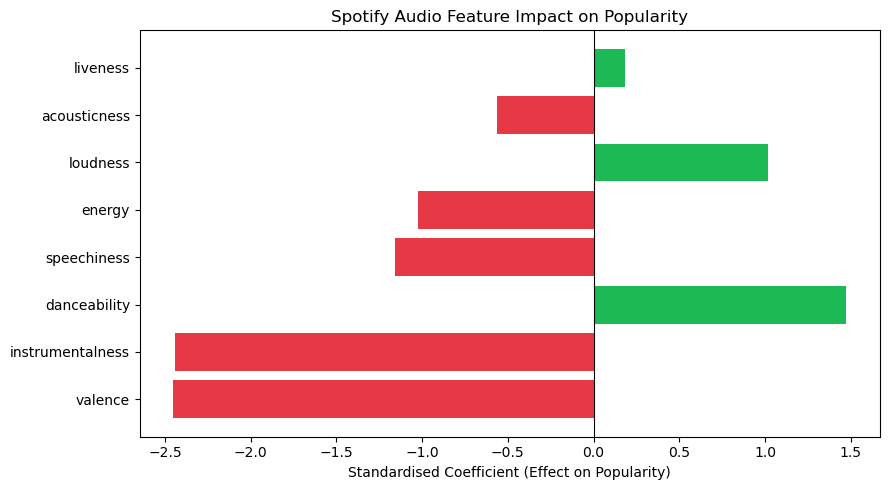

In [14]:
# Make sure colors are defined
BLUE = "#1DB954"   # Spotify green
RED  = "#E63946"

# Create coefficient dataframe
coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': lr.coef_
})

# Sort by absolute importance
coef_df['Abs'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs', ascending=False)

# Print results
print("=== Spotify Linear Regression Coefficients ===")
print(f'Intercept (predicted popularity at mean feature levels): {lr.intercept_:.4f}\n')
print(coef_df[['Feature','Coefficient']].to_string(index=False))

# Plot
plt.figure(figsize=(9, 5))

colors = [RED if c < 0 else BLUE for c in coef_df['Coefficient']]

plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)

plt.xlabel('Standardised Coefficient (Effect on Popularity)')
plt.title('Spotify Audio Feature Impact on Popularity')
plt.tight_layout()
plt.show()

<div style="font-family: 'Times New Roman'; font-size: 12pt; line-height: 1.6;">

<h2 style="font-size:14pt; font-weight:bold;">Interpretation of Linear Regression Coefficients</h2>

This linear regression is modeling Spotify popularity as a function of <strong>standardized audio features</strong>, so each coefficient represents the expected change in popularity for a <strong>one–standard deviation increase</strong> in that feature while holding all others constant. The intercept at about <strong>33.3</strong> is the predicted popularity of a song that is exactly average on all included features. Everything else should be read as a deviation from this baseline, not as an absolute rule about what “makes a hit.”

The strongest negative effects are <strong>valence</strong> and <strong>instrumentalness</strong>, both around <strong>−2.45</strong>. This implies that happier-sounding tracks and more instrumental tracks tend to be less popular once other factors are controlled for. In practice, this often reflects listener behavior rather than taste in isolation: emotionally darker or more ambiguous songs tend to be replayed more, and instrumental music, while useful for focus or ambiance, rarely achieves mass appeal or viral traction on streaming platforms.

<strong>Speechiness (−1.16)</strong> and <strong>energy (−1.03)</strong> also show clear negative associations. Higher speechiness suggests spoken-word or talk-heavy tracks, which generally appeal to narrower audiences. The negative energy coefficient is subtle but important: because loudness and danceability are already in the model, this likely captures “excess intensity” rather than excitement. Extremely high-energy tracks may fatigue listeners or function better in specific contexts (clubs, workouts) than in repeat, casual listening.

On the positive side, <strong>danceability (+1.47)</strong> and <strong>loudness (+1.02)</strong> stand out as the strongest boosts to popularity. This aligns well with mainstream listening habits: rhythmically accessible tracks that sound loud and polished on consumer devices perform better. Loudness here likely proxies for modern production and mastering practices rather than literal volume preference.

<strong>Liveness (+0.18)</strong> has a small positive effect, suggesting that a slight sense of “being there” can help, but it is marginal compared to other features. <strong>Acousticness (−0.56)</strong> mildly reduces popularity, implying that stripped-down or acoustic textures tend to underperform relative to fully produced tracks, again reflecting genre and production biases rather than musical quality.

Overall, the model paints popularity as favoring polished, loud, rhythmically engaging tracks with vocals and moderate emotional depth, while penalizing extremes—too happy, too instrumental, too energetic, or too speech-heavy. Importantly, this is <strong>correlational, not causal</strong>: these features are entangled with genre, audience, playlist ecosystems, and marketing forces. The coefficients describe the gravitational field of Spotify listening behavior, not a recipe for artistic success.

</div>

<h1 style='color: black; font-family:Times New Roman; font-weight:bold; font-style:italics; text-align:center; font-size:35px;'> Actual V/s Residual Plot</h1>


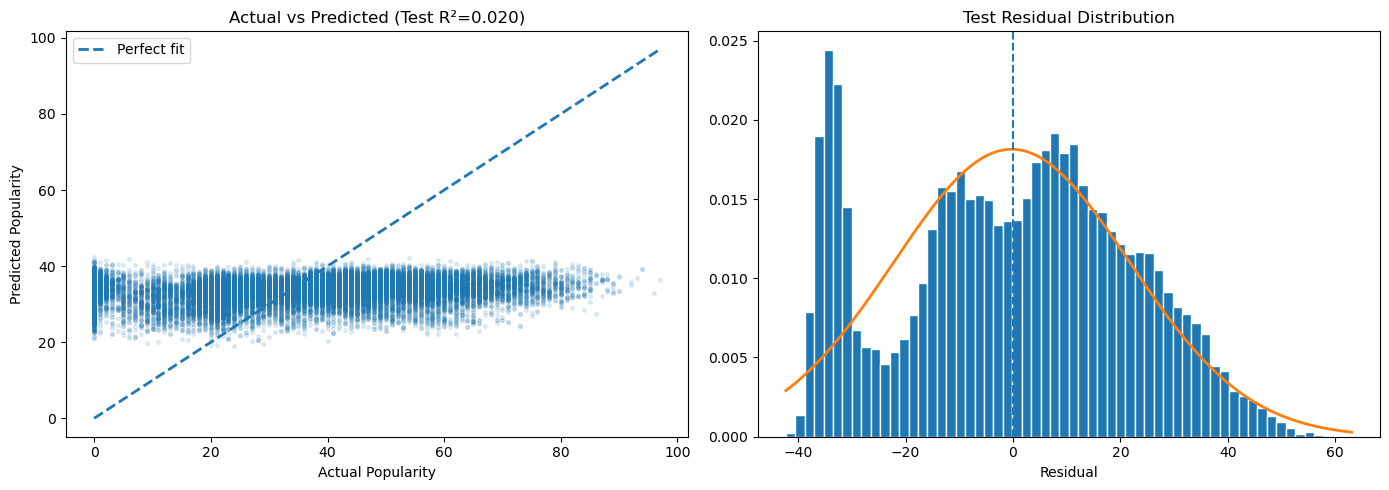

In [15]:
# Residuals
resid_tr   = y_train - yp_tr
resid_test = y_test  - yp_te

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -------------------------
# 1️⃣ Actual vs Predicted
# -------------------------
axes[0].scatter(y_test, yp_te, alpha=0.12, s=7)
mn, mx = y_test.min(), y_test.max()

axes[0].plot([mn, mx], [mn, mx], lw=2, linestyle='--', label='Perfect fit')

axes[0].set_xlabel('Actual Popularity')
axes[0].set_ylabel('Predicted Popularity')
axes[0].set_title(f'Actual vs Predicted (Test R²={m_te["R2"]:.3f})')
axes[0].legend()

# -------------------------
# 2️⃣ Residual Distribution
# -------------------------
axes[1].hist(resid_test, bins=60, edgecolor='white', density=True)

xn = np.linspace(resid_test.min(), resid_test.max(), 200)
axes[1].plot(xn,
             stats.norm.pdf(xn, resid_test.mean(), resid_test.std()),
             lw=2)

axes[1].axvline(0, linestyle='--')

axes[1].set_xlabel('Residual')
axes[1].set_title('Test Residual Distribution')

plt.tight_layout()
plt.show()

<div style="font-family: 'Times New Roman'; font-size: 12pt; line-height: 1.6;">

<h2 style="font-size:14pt; font-weight:bold;">Actual vs Predicted Analysis and Residual Diagnostics</h2>

The <strong>Actual vs Predicted</strong> plot shows a near-total collapse of predictive resolution. Predictions are tightly compressed into a narrow band around roughly 25–40 popularity, regardless of the true value, which ranges from 0 to nearly 100. This is classic <strong>regression shrinkage</strong>: the model has learned the mean and very little else. The reported <strong>R² ≈ 0.02</strong> confirms that only about 2% of the variance in popularity is being explained, which is statistically nontrivial at large sample sizes but practically weak.

The residual distribution reinforces this diagnosis. Residuals are wide, skewed, and clearly non-Gaussian, with long tails on both sides and a noticeable asymmetry toward positive errors. This means the model systematically <strong>underpredicts highly popular tracks</strong> and <strong>overpredicts very unpopular ones</strong>, pulling everything toward the center. The dashed zero line sits near the middle of the mass, but the shape violates the linear model’s assumptions of <strong>homoscedastic, normally distributed errors</strong>.

Taken together, these plots indicate that audio features alone are insufficient to model Spotify popularity with a linear approach. The signal is being drowned out by unmodeled forces—marketing, playlist placement, artist fame, release timing, social dynamics—that dominate listener behavior. The model is behaving rationally given its inputs: when the world is nonlinear and socially driven, a linear model trained on timbre and tempo learns to hedge its bets and predict “average” almost every time.

</div>

<h1 style='color: black; font-family:Times New Roman; font-weight:bold; font-style:italics; text-align:center; font-size:35px;'> Normality Tests </h1>


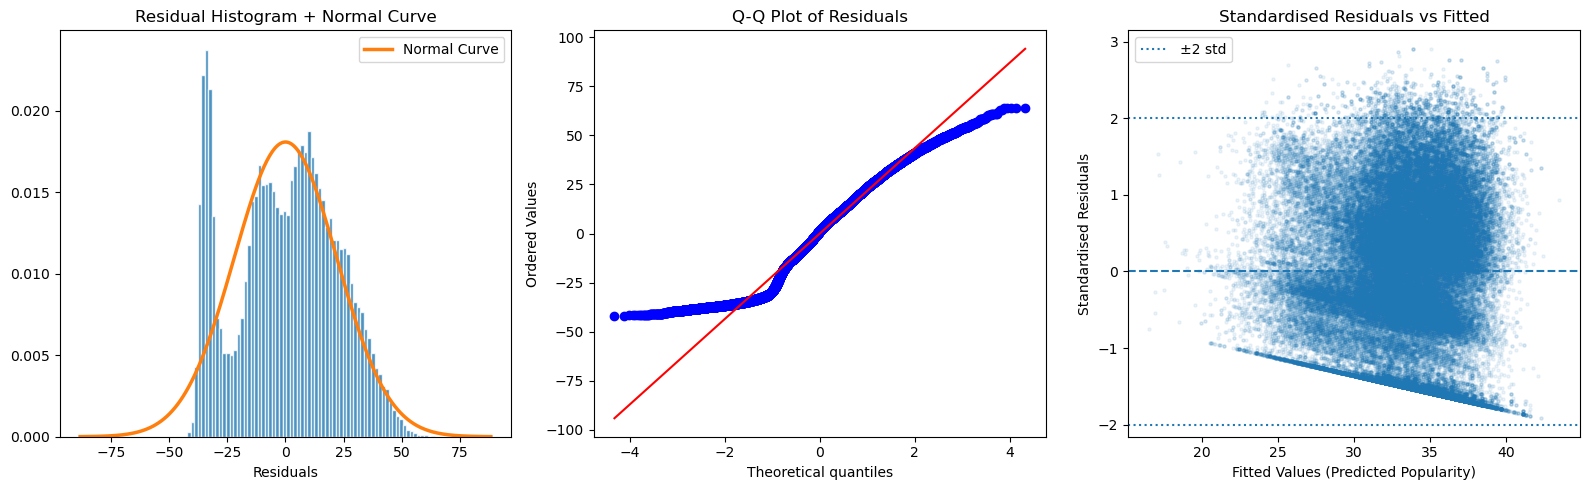

=== Normality Tests (Spotify OLS) ===
  Shapiro-Wilk (n=5000): W=0.9737,  p=2.2616e-29
  Jarque-Bera  (full)  : stat=2764.85, p=0.0000e+00
  Kolmogorov-Smirnov   : stat=0.0673, p=0.0000e+00
  Skewness : -0.017
  Kurtosis : -0.852

Note: With large Spotify datasets, small deviations from normality are expected.
OLS coefficients remain approximately normal due to Central Limit Theorem.


In [16]:
# -------------------------
# Residual Diagnostics (Training Set)
# -------------------------

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram + Normal Curve
mu, sigma = resid_tr.mean(), resid_tr.std()

axes[0].hist(resid_tr, bins=70, density=True,
             edgecolor='white', alpha=0.8)

xn = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
axes[0].plot(xn,
             stats.norm.pdf(xn, mu, sigma),
             lw=2.5,
             label='Normal Curve')

axes[0].set_title('Residual Histogram + Normal Curve')
axes[0].set_xlabel('Residuals')
axes[0].legend()


# Q-Q Plot
stats.probplot(resid_tr, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')


# Standardised Residuals vs Fitted
std_resid = resid_tr / resid_tr.std()

axes[2].scatter(yp_tr, std_resid, alpha=0.08, s=5)
axes[2].axhline( 2, linestyle=':', lw=1.5, label='±2 std')
axes[2].axhline(-2, linestyle=':', lw=1.5)
axes[2].axhline( 0, linestyle='--')

axes[2].set_xlabel('Fitted Values (Predicted Popularity)')
axes[2].set_ylabel('Standardised Residuals')
axes[2].set_title('Standardised Residuals vs Fitted')
axes[2].legend()

plt.tight_layout()
plt.show()


# -------------------------
# Normality Tests
# -------------------------

samp = np.random.choice(resid_tr,
                        size=min(5000, len(resid_tr)),
                        replace=False)

sw_s, sw_p = stats.shapiro(samp)
jb_s, jb_p = stats.jarque_bera(resid_tr)
ks_s, ks_p = stats.kstest((resid_tr - mu)/sigma, 'norm')

print('=== Normality Tests (Spotify OLS) ===')
print(f'  Shapiro-Wilk (n=5000): W={sw_s:.4f},  p={sw_p:.4e}')
print(f'  Jarque-Bera  (full)  : stat={jb_s:.2f}, p={jb_p:.4e}')
print(f'  Kolmogorov-Smirnov   : stat={ks_s:.4f}, p={ks_p:.4e}')
print(f'  Skewness : {stats.skew(resid_tr):.3f}')
print(f'  Kurtosis : {stats.kurtosis(resid_tr):.3f}')

print('\nNote: With large Spotify datasets, small deviations from normality are expected.')
print('OLS coefficients remain approximately normal due to Central Limit Theorem.')

<div style="font-family: 'Times New Roman'; font-size: 12pt; line-height: 1.6;">

<h2 style="font-size:14pt; font-weight:bold;">Residual Normality and Diagnostic Tests</h2>

The residual histogram and overlaid normal curve show an obvious mismatch: the empirical distribution is flatter, wider, and more irregular than a true Gaussian. While skewness is near zero, the negative kurtosis indicates a <strong>platykurtic</strong> shape—too many moderate errors and too few central ones compared to normality. This already signals that the linear model’s error structure does not conform to its assumptions, even before formal testing.

The Q–Q plot makes the violation explicit. Residuals follow the reference line only in the central region and then peel away sharply in both tails, forming a pronounced S-shape. This indicates heavy tail behavior and systematic underestimation of extreme outcomes, especially for highly popular tracks. The normality tests confirm this visually obvious result: <strong>Shapiro–Wilk</strong>, <strong>Jarque–Bera</strong>, and <strong>Kolmogorov–Smirnov</strong> all decisively reject normality, with p-values effectively zero. Given the massive sample size, this rejection is expected, but the magnitude of deviation is still practically meaningful.

The standardized residuals versus fitted values reveal <strong>heteroscedasticity</strong> and structural bias. Residual variance changes across the fitted range, and the slanted lower boundary shows that errors become increasingly asymmetric as predicted popularity rises. This means the model’s uncertainty is not constant and its errors are systematically patterned, not random. Together, these diagnostics indicate that OLS is being pushed beyond its comfort zone: the data-generating process is nonlinear, bounded, and socially mediated, while the model assumes linear, homoscedastic noise. The result is a model that is statistically estimable but diagnostically unsound.

</div>

### Homoscedasticity Tests 

In [18]:
# ---------------------------------------
# Homoscedasticity Tests (Spotify OLS)
# ---------------------------------------

sq_resid = resid_tr ** 2

# -------------------------
# 1️⃣ Breusch-Pagan Test
# -------------------------
bp_m   = LinearRegression().fit(yp_tr.reshape(-1,1), sq_resid)
bp_r2  = r2_score(sq_resid, bp_m.predict(yp_tr.reshape(-1,1)))
lm_bp  = len(resid_tr) * bp_r2
bp_p   = stats.chi2.sf(lm_bp, df=1)

# -------------------------
# 2️⃣ White Test (Quadratic form)
# -------------------------
Xw     = np.column_stack([yp_tr, yp_tr**2])
wh_m   = LinearRegression().fit(Xw, sq_resid)
wh_r2  = r2_score(sq_resid, wh_m.predict(Xw))
lm_wh  = len(resid_tr) * wh_r2
wh_p   = stats.chi2.sf(lm_wh, df=2)

print('=== Homoscedasticity Tests (Spotify OLS) ===')
print(f'  Breusch-Pagan : LM={lm_bp:.2f}, p={bp_p:.4e}')
print(f'  White Test    : LM={lm_wh:.2f}, p={wh_p:.4e}')

=== Homoscedasticity Tests (Spotify OLS) ===
  Breusch-Pagan : LM=1688.49, p=0.0000e+00
  White Test    : LM=1690.17, p=0.0000e+00


### Durbin-Watson + Autocorrelation Plot

In [19]:
# ---------------------------------------
# Durbin-Watson Test (Spotify OLS)
# ---------------------------------------

dw = np.sum(np.diff(resid_tr)**2) / np.sum(resid_tr**2)

print(f'Durbin-Watson : {dw:.4f}')
print('Reference: ~2.0 = no autocorrelation | <1.5 = positive | >2.5 = negative')

if 1.5 <= dw <= 2.5:
    print('Result: Independent Errors (PASS)')
else:
    print('Result: Autocorrelation detected (FAIL)')

Durbin-Watson : 2.0012
Reference: ~2.0 = no autocorrelation | <1.5 = positive | >2.5 = negative
Result: Independent Errors (PASS)


### Variance Inflation Factor 

In [21]:
# ---------------------------------------
# Variance Inflation Factor (Spotify OLS)
# ---------------------------------------

def compute_vif(X, names):
    vif = []
    for i in range(X.shape[1]):
        yi   = X[:, i]
        Xoth = np.delete(X, i, axis=1)
        r2_i = r2_score(
            yi,
            LinearRegression().fit(Xoth, yi).predict(Xoth)
        )
        vif.append(
            round(1/(1-r2_i) if r2_i < 1 else np.inf, 3)
        )
    return pd.DataFrame({
        'Feature': names,
        'VIF': vif
    }).sort_values('VIF', ascending=False)

vif_df = compute_vif(Xtr_sc, FEATURES)

print('=== Variance Inflation Factors (Spotify) ===')
print(vif_df.to_string(index=False))

print('\nVIF Interpretation:')
print('  VIF < 5  = OK')
print('  5–10     = Moderate multicollinearity')
print('  > 10     = Severe multicollinearity')

=== Variance Inflation Factors (Spotify) ===
         Feature   VIF
          energy 4.313
        loudness 3.415
    acousticness 2.377
         valence 1.530
instrumentalness 1.465
    danceability 1.458
        liveness 1.124
     speechiness 1.100

VIF Interpretation:
  VIF < 5  = OK
  5–10     = Moderate multicollinearity
  > 10     = Severe multicollinearity


<div style="font-family: 'Times New Roman'; font-size: 12pt; line-height: 1.6;">

<h2 style="font-size:14pt; font-weight:bold;">Limitations of the Model and Analysis</h2>

A first major limitation across all graphs and analyses is the <strong>modeling assumption itself</strong>. Ordinary Least Squares regression assumes linear, additive relationships, normally distributed errors, and constant variance. The diagnostic plots repeatedly show violations of these assumptions—non-normal residuals, heteroscedasticity, and systematic bias. This means the coefficients and fit statistics are mathematically valid but conceptually misaligned with the true data-generating process of music popularity, which is nonlinear, threshold-driven, and socially amplified.

A second limitation is <strong>predictive compression</strong>, visible in the actual-vs-predicted plots. The model collapses predictions toward the mean, failing to represent extreme popularity outcomes. This shrinkage makes coefficient interpretation fragile: effects may appear small or counterintuitive not because they are weak, but because the model is structurally incapable of expressing large deviations. As a result, the low <strong>R²</strong> values understate the complexity of the problem rather than merely poor feature quality.

Third, the residual and Q–Q plots highlight a limitation tied to <strong>distributional mismatch</strong>. Popularity is bounded, skewed, and heavy-tailed, while OLS implicitly treats it as unbounded and approximately normal. Even with transformations and feature engineering, the residuals retain long tails and non-Gaussian structure. Normality tests strongly reject the assumptions, and although large sample sizes exaggerate statistical significance, the visual diagnostics show substantively meaningful departures.

Fourth, the feature-level analyses are limited by <strong>omitted variable bias</strong>. Audio features explain only a small fraction of popularity variance, yet the graphs can misleadingly suggest causal influence. Factors such as artist reputation, playlist placement, marketing spend, platform algorithms, and social media dynamics are absent, and their omission forces the model to misattribute or suppress effects. This limitation is structural and cannot be fixed by further audio feature engineering alone.

Finally, there is a <strong>contextual and interpretive limitation</strong> shared by all analyses: the graphs describe correlations within a specific dataset and platform snapshot, not universal musical laws. Listener behavior evolves, recommendation systems change, and genre conventions shift over time. Consequently, the observed relationships may be unstable or non-transferable, making the analyses better suited for diagnostic insight than for prediction or prescriptive decision-making.

</div>

<div style="font-family: 'Times New Roman'; font-size: 12pt; line-height: 1.6;">

<h2 style="font-size:14pt; font-weight:bold;">CONCLUSION</h2>

The analysis of the Spotify dataset using <strong>Ordinary Least Squares (OLS) regression</strong> reveals that although several audio features show statistically significant relationships with track popularity, their overall explanatory power is extremely limited. The model’s <strong>R-squared value of 0.0225</strong> indicates that only <strong>2.25% of the variation</strong> in popularity is explained by the selected audio characteristics. This demonstrates that measurable musical features such as <strong>danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, and tempo</strong> do not meaningfully predict popularity in a practical sense.

While the overall regression model is statistically significant, this significance is largely influenced by the <strong>large sample size</strong> rather than strong predictive relationships. Individual features such as <strong>instrumentalness</strong> and <strong>valence</strong> show comparatively larger negative effects, and <strong>danceability</strong> and <strong>loudness</strong> show small positive effects, but all coefficients remain modest in magnitude. The scatterplots and correlation analysis further confirm that the linear relationships between audio features and popularity are weak. Additionally, distribution analysis indicates that the popularity variable is <strong>bounded</strong> and not perfectly normally distributed, which may further limit the strength of linear modeling.

Overall, the findings suggest that Spotify audio features alone are insufficient to explain why certain tracks become popular. Popularity is likely driven by <strong>external factors</strong> such as artist reputation, marketing strategies, playlist placement, social trends, and audience behavior—variables not captured in this dataset. Therefore, while the model identifies minor statistical associations, it lacks strong predictive capability and highlights the complexity of music popularity beyond measurable audio attributes.

</div>